# Regression analysis

In [1]:
import re
import os
import pandas as pd
from statsmodels.formula.api import ols

In [2]:
data = pd.read_csv('../data/viral/metadata/SARS2_BA1_SPIKE_Dadonaite.csv')
data

,ID,mutant,num_mutations,target,sequence
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...


In [3]:
mutation = 'N310T'

def split_mut_sit(mutation):
    parts = re.match(r'([A-Za-z])(\d+)(\S)', mutation) # \S for any non- white space
    if parts:
        return list(parts.groups())
    else:
        return [None, None, None]

split_mut_sit(mutation)

['N', '310', 'T']

In [4]:
data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
data

,ID,mutant,num_mutations,target,sequence,wt,site,mut
0,SARS2_BA1_M1I,M1I,1,-2.2303,IFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,I
1,SARS2_BA1_M1M,M1M,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,M
2,SARS2_BA1_M1T,M1T,1,-2.4823,TFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,T
3,SARS2_BA1_M1V,M1V,1,-2.3068,VFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,M,1,V
4,SARS2_BA1_F2F,F2F,1,0.0000,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,F,2,F
...,...,...,...,...,...,...,...,...
10793,SARS2_BA1_S1249F,S1249F,1,0.3970,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,F
10794,SARS2_BA1_S1249E,S1249E,1,-0.0168,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,E
10795,SARS2_BA1_S1249C,S1249C,1,0.3963,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,C
10796,SARS2_BA1_S1249A,S1249A,1,-0.0001,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,S,1249,A


In [18]:
data.dtypes

ID                object
mutant            object
num_mutations      int64
target           float64
sequence          object
wt                object
site              object
mut               object
dtype: object

In [12]:
model = ols('target ~ site', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     6.196
Date:                Fri, 05 Sep 2025   Prob (F-statistic):               0.00
Time:                        15:28:09   Log-Likelihood:                -12957.
No. Observations:               10798   AIC:                         2.841e+04
Df Residuals:                    9549   BIC:                         3.751e+04
Df Model:                        1248                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.7549      0.427     -4.109   

# Viral

In [13]:
base_dir = '../data/viral/metadata/'
res = {}
for file in os.listdir(base_dir):
    file_path = os.path.join(base_dir, file)
    dts = file.split('.csv')[0]
    data = pd.read_csv(file_path)
    
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data['site'] = data['site'].astype(str)
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]


df = pd.DataFrame.from_dict(res, orient='index').reset_index()
df.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df['Source'] = 'Viral'
df

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,HIV1_HV1B9_ENV_DuenasDecamp,0.3107,0.0398,0.3486,Viral
1,BPP22_COAT_Tsuboyama,0.6027,0.1601,0.7677,Viral
2,AAV2_CAPSD_Sinai,0.2419,0.0799,0.2958,Viral
3,IAV_RDRP_Li,0.3660,0.0515,0.4163,Viral
4,EV_CAPSD_Bakhache,0.3232,0.0362,0.3599,Viral
5,CVB3_2B_Alvarez,0.3422,0.1158,0.4581,Viral
6,CVB3_3B_Alvarez,0.4537,0.0711,0.5248,Viral
7,PESV_POLG_Tsuboyama,0.4946,0.0666,0.5531,Viral
8,RsYN04_RBD_Starr,0.6774,0.0062,0.6834,Viral
9,DENV_POLG_Suphatrakul,0.5958,0.0537,0.6494,Viral


## Cellular

In [19]:
base_dir = '../data/nonviral/metadata/'
res_nonviral = {}
for file in os.listdir(base_dir):
    dts = file.split('.csv')[0]
    file_path = os.path.join(base_dir, file)
    data = pd.read_csv(file_path)
    data[['wt', 'site', 'mut']] = data['mutant'].apply(lambda x: pd.Series(split_mut_sit(x)))
    data = data.dropna()
    model1 = ols('target ~ site', data=data).fit()
    model2 = ols('target ~ mut', data=data).fit()
    model3 = ols('target ~ site+mut', data=data).fit()
    res_nonviral[dts] = [round(float(model1.rsquared), 4), round(float(model2.rsquared), 4), round(float(model3.rsquared), 4)]

df2 = pd.DataFrame.from_dict(res_nonviral, orient='index').reset_index()
df2.rename(columns={'index': 'Dataset', 0:'R2_site', 1:'R2_mut', 2:'R2_site+mut'}, inplace=True)
df2['Source'] = 'Cellular'
df2

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,TIM_THETH,0.4950,0.0629,0.5578,Cellular
1,TIM_THEMA,0.4405,0.0460,0.4836,Cellular
2,MK01_HUMAN_Johannessen,0.2512,0.0356,0.2861,Cellular
3,IF1_ECOLI,0.5028,0.0872,0.5903,Cellular
4,TIM_SULSO,0.4565,0.0691,0.5257,Cellular
5,RL401_YEAST_Fraser2016,0.4519,0.0630,0.5154,Cellular
6,RASH_HUMAN_Kuriyan,0.5455,0.0513,0.5948,Cellular
7,MTH3_HAEAESTABILIZED_Tawfik2015,0.5626,0.0356,0.5813,Cellular
8,AMIE_PSEAE_Whitehead,0.4708,0.0449,0.5166,Cellular
9,TPMT_HUMAN_Fowler2018,0.3431,0.1491,0.4886,Cellular


In [20]:
res_full = pd.concat([df, df2])
res_melt = res_full.melt(id_vars=['Dataset', 'Source'], value_vars=['R2_site', 'R2_mut', 'R2_site+mut'], var_name='Model', value_name='R2')
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,R2_site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,R2_site,0.6027
2,AAV2_CAPSD_Sinai,Viral,R2_site,0.2419
3,IAV_RDRP_Li,Viral,R2_site,0.3660
4,EV_CAPSD_Bakhache,Viral,R2_site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Cellular,R2_site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Cellular,R2_site+mut,0.4354
234,RL401_YEAST_Bolon2013,Cellular,R2_site+mut,0.5773
235,RL401_YEAST_Bolon2014,Cellular,R2_site+mut,0.5871


In [ ]:
#res_melt.to_csv('../experiments/OLS_results.csv')

# PLots

In [23]:
import pandas as pd
import plotnine as pln

# res_melt = pd.read_csv('../experiments/OLS_results.csv', index_col=0)
# res_melt

In [21]:
res_melt['Model'] = res_melt['Model'].str.replace('R2_', '',)
res_melt

,Dataset,Source,Model,R2
0,HIV1_HV1B9_ENV_DuenasDecamp,Viral,site,0.3107
1,BPP22_COAT_Tsuboyama,Viral,site,0.6027
2,AAV2_CAPSD_Sinai,Viral,site,0.2419
3,IAV_RDRP_Li,Viral,site,0.3660
4,EV_CAPSD_Bakhache,Viral,site,0.3232
...,...,...,...,...
232,B3VI55_LIPST_Whitehead2015,Cellular,site+mut,0.2705
233,B3VI55_LIPSTSTABLE,Cellular,site+mut,0.4354
234,RL401_YEAST_Bolon2013,Cellular,site+mut,0.5773
235,RL401_YEAST_Bolon2014,Cellular,site+mut,0.5871


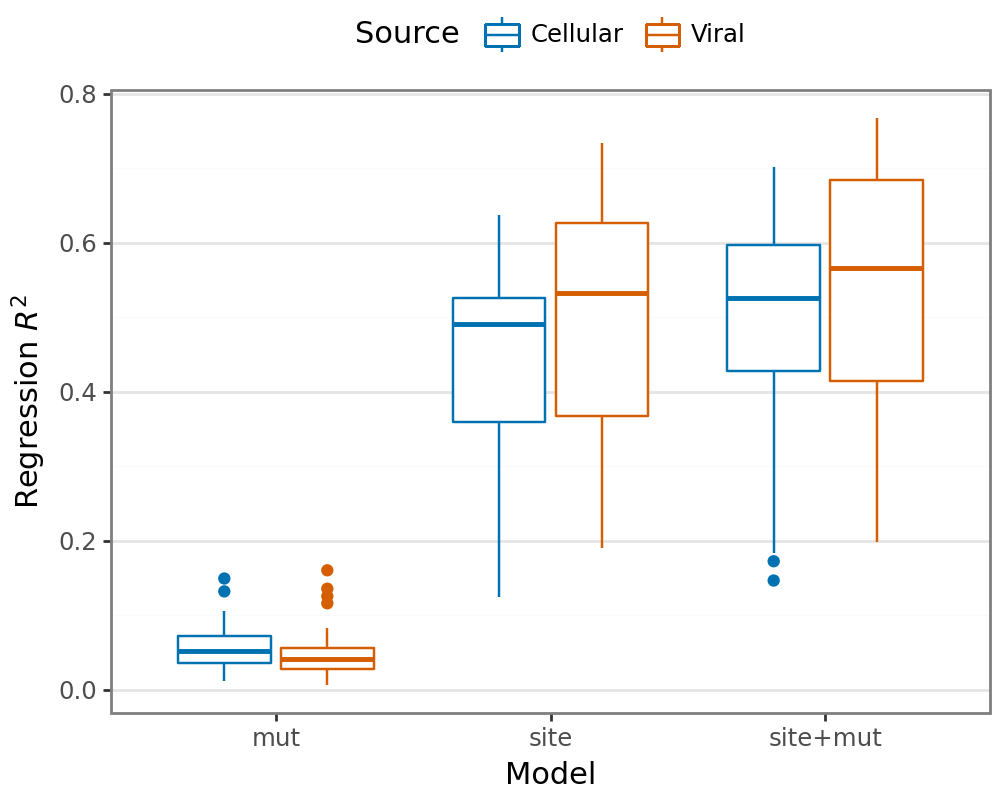

In [25]:
plot = (
    #pln.ggplot(res_melt, pln.aes(y='R2', x='Source', color='Model'))
    pln.ggplot(res_melt, pln.aes(y='R2', x='Model', color='Source'))
    + pln.scale_color_manual(values={"Viral": "#D55E00", "Cellular": "#0072B2"})
    + pln.geom_boxplot()
    + pln.theme_bw()
    + pln.theme(figure_size=(5,4), panel_grid_major_x=pln.element_blank(), legend_position='top')
    +pln.labs(
        y='Regression $R^2$'
    )
    )

plot#.save('../experiments/regression/regression_site_categorical_source.png', dpi=600)

# diff pool-ss x R2

In [61]:
ols_res = pd.concat([df, df2])
ols_res

,Dataset,R2_site,R2_mut,R2_site+mut,Source
0,HIV1_HV1B9_ENV_DuenasDecamp,0.3107,0.0398,0.3486,Viral
1,BPP22_COAT_Tsuboyama,0.6027,0.1601,0.7677,Viral
2,AAV2_CAPSD_Sinai,0.2419,0.0799,0.2958,Viral
3,IAV_RDRP_Li,0.3660,0.0515,0.4163,Viral
4,EV_CAPSD_Bakhache,0.3232,0.0362,0.3599,Viral
...,...,...,...,...,...
30,B3VI55_LIPST_Whitehead2015,0.2583,0.0114,0.2705,Cellular
31,B3VI55_LIPSTSTABLE,0.3559,0.0732,0.4354,Cellular
32,RL401_YEAST_Bolon2013,0.4950,0.0760,0.5773,Cellular
33,RL401_YEAST_Bolon2014,0.5197,0.0710,0.5871,Cellular


In [63]:
ols_site = {k:v for k, v in zip(ols_res['Dataset'], ols_res['R2_site'])}
ols_site 

{'HIV1_HV1B9_ENV_DuenasDecamp': 0.3107,
 'BPP22_COAT_Tsuboyama': 0.6027,
 'AAV2_CAPSD_Sinai': 0.2419,
 'IAV_RDRP_Li': 0.366,
 'EV_CAPSD_Bakhache': 0.3232,
 'CVB3_2B_Alvarez': 0.3422,
 'CVB3_3B_Alvarez': 0.4537,
 'PESV_POLG_Tsuboyama': 0.4946,
 'RsYN04_RBD_Starr': 0.6774,
 'DENV_POLG_Suphatrakul': 0.5958,
 'HIV1_BG505_ENV_Haddox': 0.6581,
 'IAV_PB2_Soh': 0.5504,
 'CVB3_POLG_Mattenberger': 0.5434,
 'IAV_NA_Jiang': 0.6146,
 'IAV_H1_HA_Wu': 0.3441,
 'BP434_RPC1_Tsuboyama': 0.6522,
 'CVB3_VP1_Alvarez': 0.3691,
 'SARS2_DELTA_SPIKE_Dadonaite': 0.1895,
 'EV_REP_Bakhache': 0.4058,
 'CVB3_3D_Alvarez': 0.3635,
 'NIPAH_F_Larsen': 0.553,
 'IAV_H5_HA_Dadonaite': 0.5539,
 'SARS2_XBB15_RBD_Taylor': 0.6678,
 'HIV1_BF520_ENV_Haddox': 0.687,
 'CVB3_VP3_Alvarez': 0.257,
 'IAV_H3_HA_Lee': 0.6206,
 'RmYN02_RBD_Starr': 0.3563,
 'IAV_H3_NP_Doud': 0.5478,
 'IAV_H1_HA_Doud': 0.6072,
 'IAV_H1_NP_Doud': 0.3708,
 'IAV_PA_Wu': 0.5219,
 'SARS2_MRPO_Flynn': 0.6998,
 'SARS2_PLPRO_abundance_Wu': 0.5173,
 'LAMBDA_HCP_Ts

In [66]:
cols=['Dataset', 'Model', 'Source', 'Split', 'Fold', 'R2_score_test']
lassoCV = pd.read_csv('../experiments_v01/lassoCV/results_4models_3folds_v_nv_SS_P.csv', usecols=cols) 
lassoCV['Source'] = lassoCV['Source'].replace('nonviral', 'cellular') 
lassoCV = lassoCV.groupby(['Dataset', 'Model', 'Source', 'Split'], as_index=False)['R2_score_test'].mean()
res_pivot = lassoCV.pivot_table(index=['Dataset', 'Model', 'Source'], columns='Split', values='R2_score_test').reset_index()
res_pivot

Split,Dataset,Model,Source,pooled,site
0,AMIE_PSEAE_Whitehead,esm2_650m,cellular,0.488876,0.304726
1,AMIE_PSEAE_Whitehead,esm2_viral_650m,cellular,0.407154,0.115632
2,AMIE_PSEAE_Whitehead,esmc_600m,cellular,0.471465,0.299144
3,AMIE_PSEAE_Whitehead,rsawhney_esm2_3B,cellular,0.567911,0.022371
4,B3VI55_LIPSTSTABLE,esm2_650m,cellular,0.449989,0.269900
...,...,...,...,...,...
291,UBE4B_MOUSE_Klevit2013_singles,rsawhney_esm2_3B,cellular,0.168433,-0.038376
292,YAP1_HUMAN_Fields2012_singles,esm2_650m,cellular,0.437652,-0.037326
293,YAP1_HUMAN_Fields2012_singles,esm2_viral_650m,cellular,0.359659,0.080724
294,YAP1_HUMAN_Fields2012_singles,esmc_600m,cellular,0.577491,0.345982


In [67]:
res_pivot['ols_site_R2'] = res_pivot['Dataset'].map(ols_site)
res_pivot

Split,Dataset,Model,Source,pooled,site,ols_site_R2
0,AMIE_PSEAE_Whitehead,esm2_650m,cellular,0.488876,0.304726,0.4708
1,AMIE_PSEAE_Whitehead,esm2_viral_650m,cellular,0.407154,0.115632,0.4708
2,AMIE_PSEAE_Whitehead,esmc_600m,cellular,0.471465,0.299144,0.4708
3,AMIE_PSEAE_Whitehead,rsawhney_esm2_3B,cellular,0.567911,0.022371,0.4708
4,B3VI55_LIPSTSTABLE,esm2_650m,cellular,0.449989,0.269900,0.3559
...,...,...,...,...,...,...
291,UBE4B_MOUSE_Klevit2013_singles,rsawhney_esm2_3B,cellular,0.168433,-0.038376,0.3766
292,YAP1_HUMAN_Fields2012_singles,esm2_650m,cellular,0.437652,-0.037326,0.5248
293,YAP1_HUMAN_Fields2012_singles,esm2_viral_650m,cellular,0.359659,0.080724,0.5248
294,YAP1_HUMAN_Fields2012_singles,esmc_600m,cellular,0.577491,0.345982,0.5248


In [ ]:
# df_vn = pd.read_csv('../experiments/viral_nonviral_splits_lassoCV_results.csv', index_col=0)
# #df_vn['diff'] = abs(df_vn['Random'] - df_vn['Site Split'])
# df_vn['diff'] = df_vn['Random'] - df_vn['Site Split']
# df_vn.rename(columns={'dataset':'Dataset'}, inplace=True)


# res = df_vn.merge(res_melt.query('Model=="site"'), how='left', on=['Dataset', 'Source'])
# res['diff_norm'] = (res['diff'] - res['diff'].min()) / (res['diff'].max() - res['diff'].min())
# res

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 6 rows containing missing values.


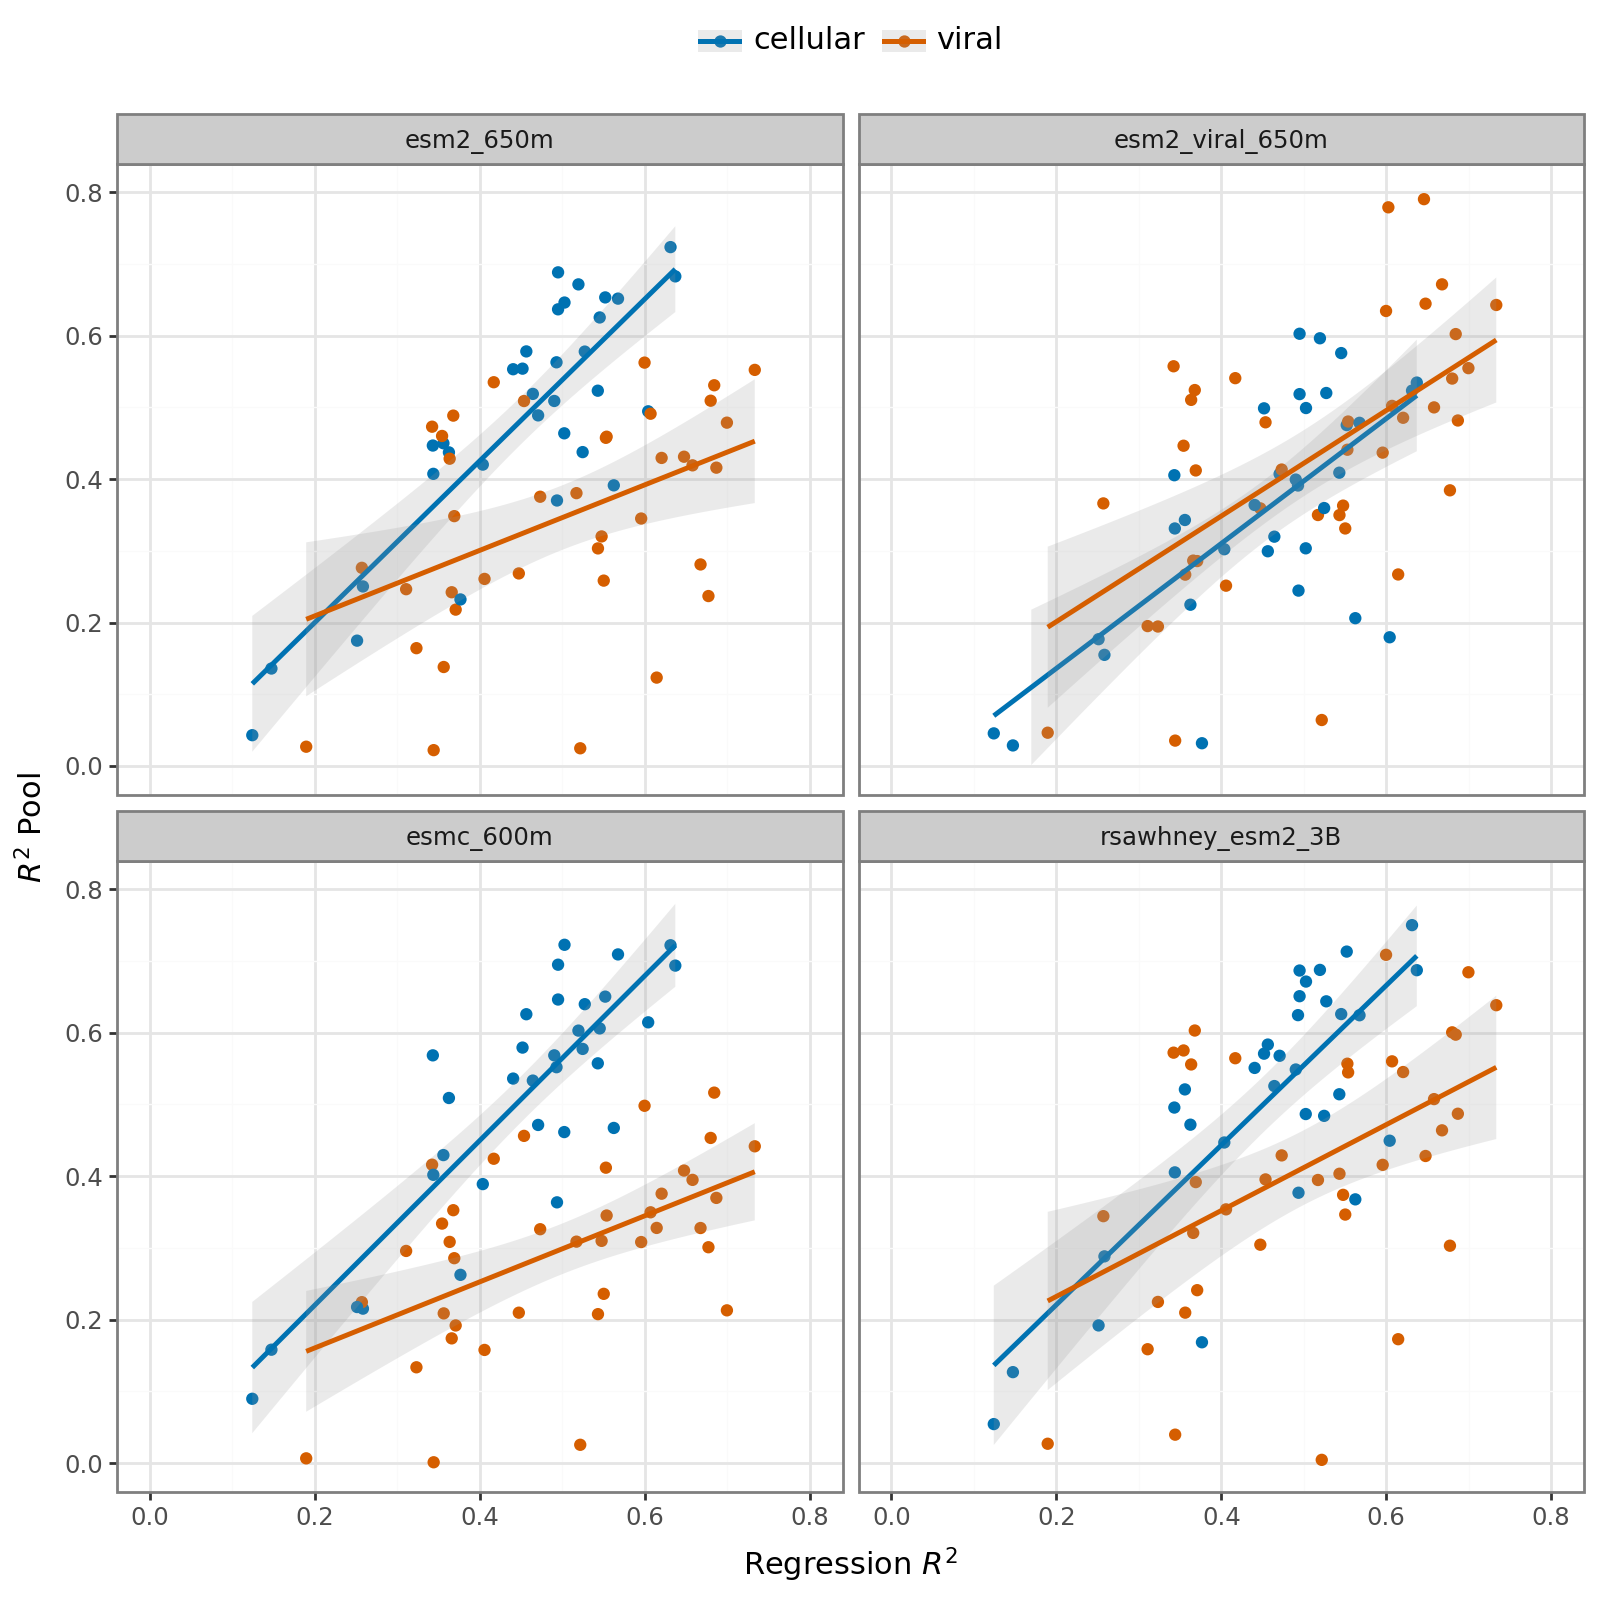

In [94]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='pooled', x='ols_site_R2', color='Source', group='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_smooth(method='lm', se=True,alpha=.2)
    + pln.theme_bw(11)
    + pln.theme(
        figure_size=(8,8),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.facet_wrap('~Model', scales='fixed')
    + pln.xlim(0, 0.8)
    + pln.ylim(0, 0.8)
    + pln.labs(
        y="$R^2$ Pool",
        x="Regression $R^2$"
    )
    )

plot#.save('../experiments/regression/diff_x_r2.png', dpi=600)

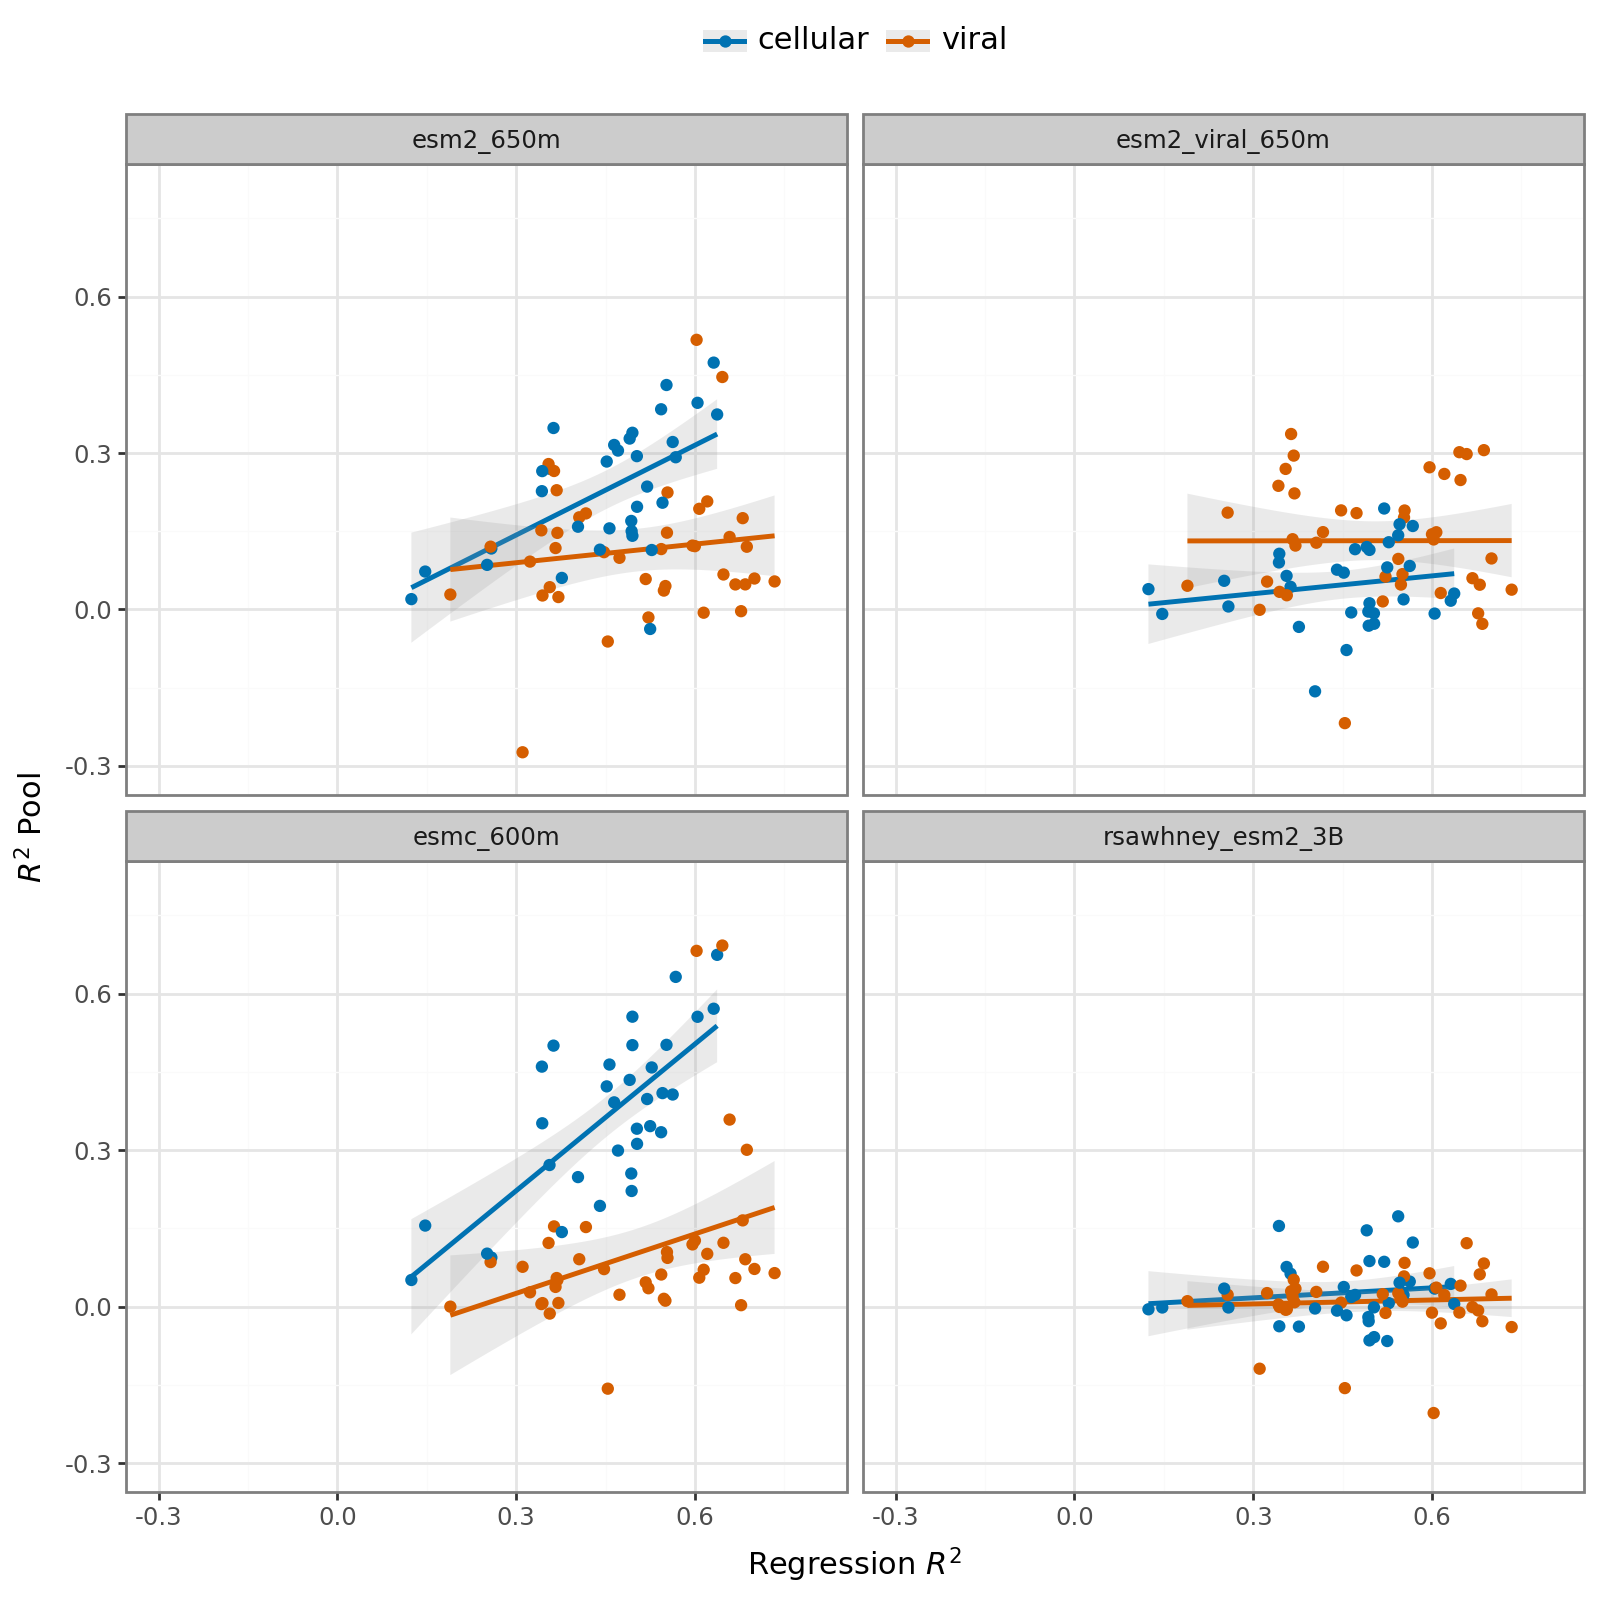

In [95]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='site', x='ols_site_R2', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_smooth(method='lm', se=True, alpha=.2)
    + pln.geom_point()
    + pln.theme_bw(11)
    + pln.theme(
        figure_size=(8,8),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.facet_wrap('~Model', scales='fixed')
    + pln.xlim(-0.3, 0.8)
    + pln.ylim(-0.3, 0.8)
    + pln.labs(
        y="$R^2$ Pool",
        x="Regression $R^2$"
    )
    )

plot#.save('../experiments/regression/ss_r2_xOLS_r2.png', dpi=600)

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 55 rows containing missing values.


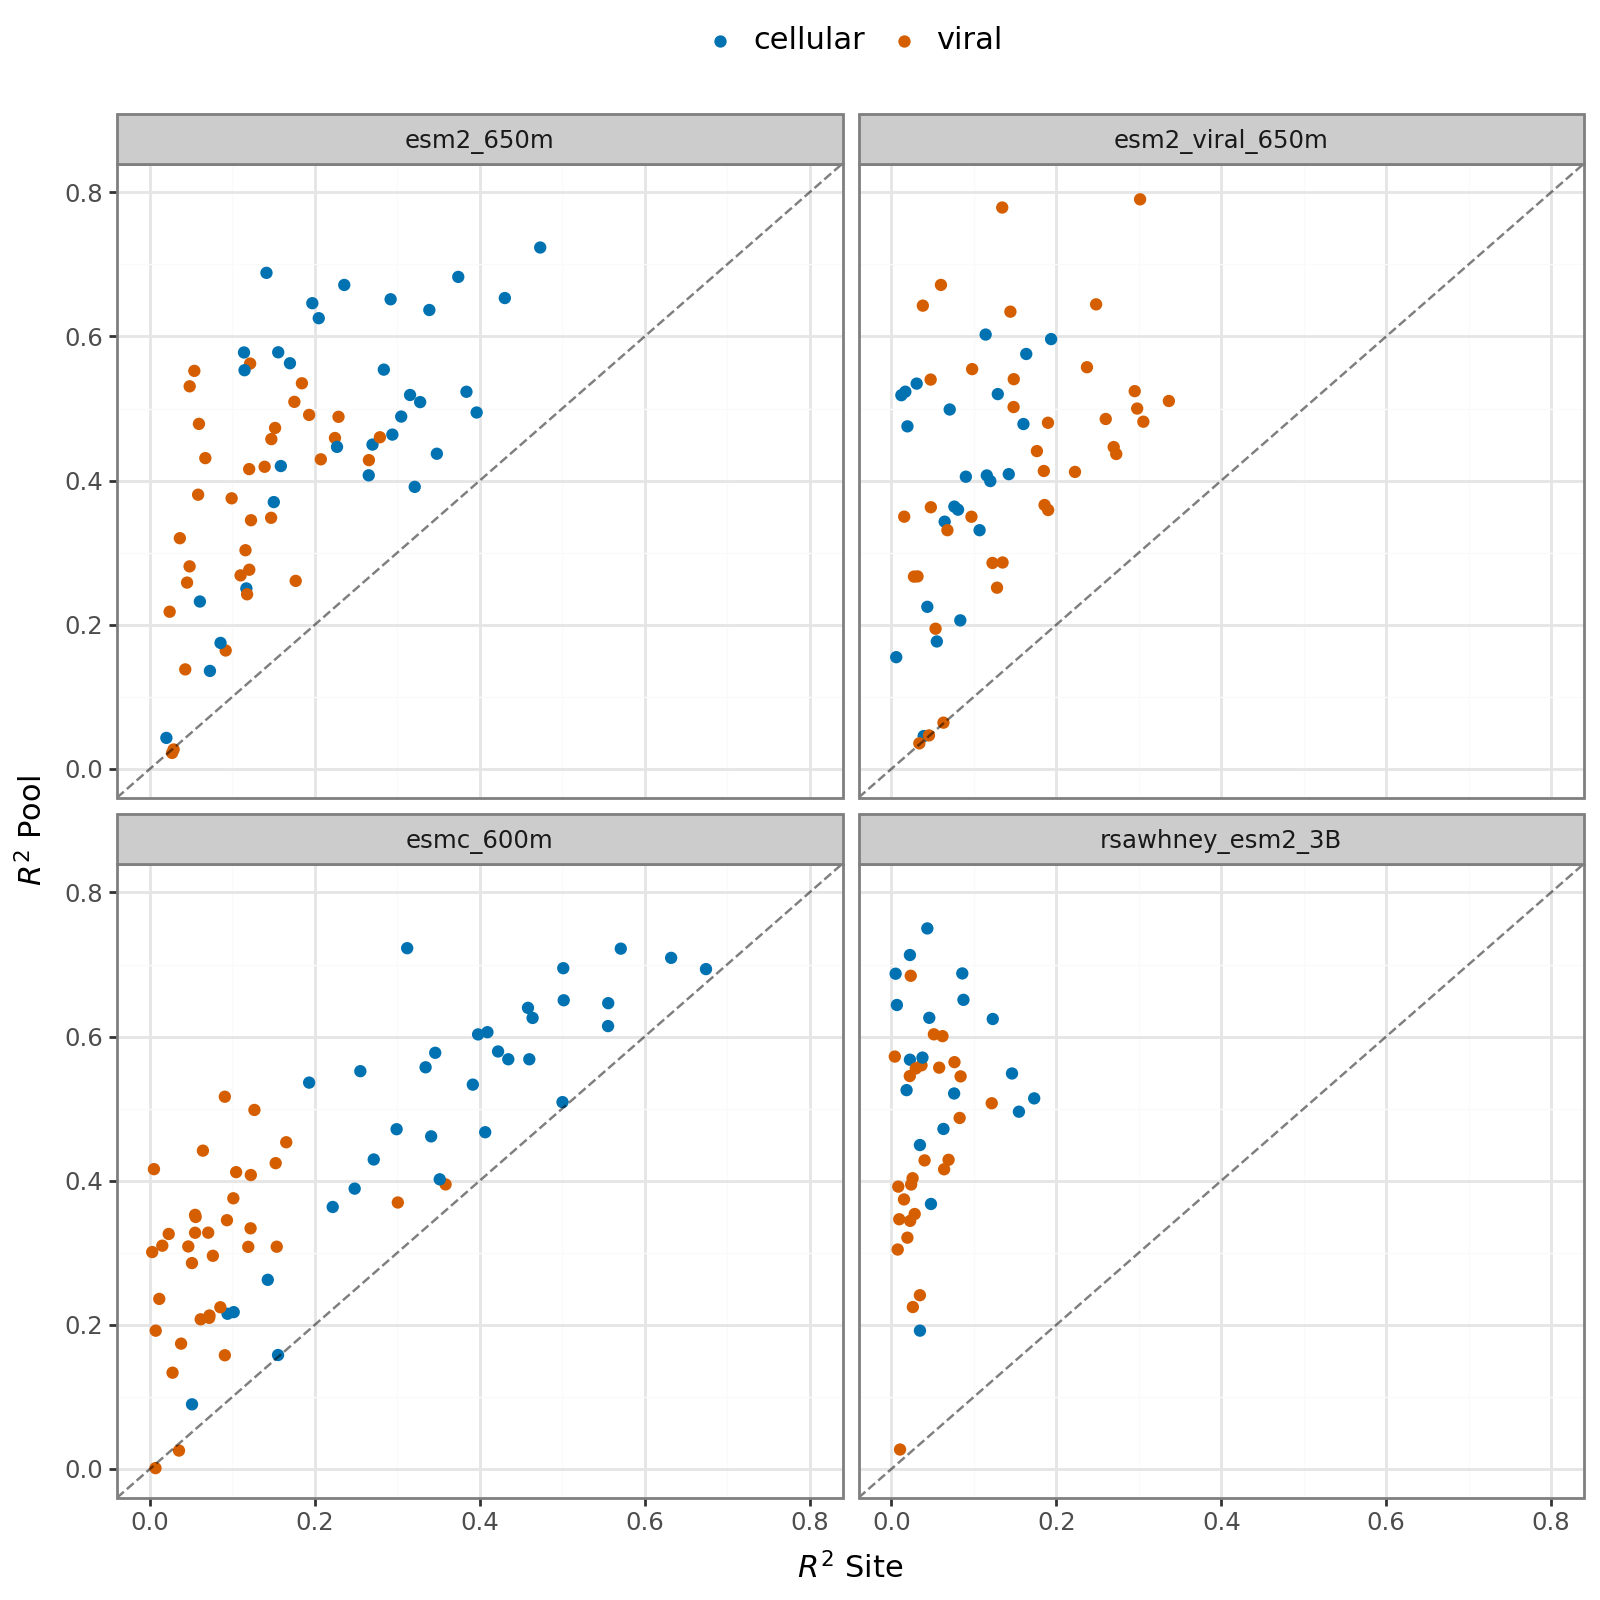

In [108]:
plot = (
    pln.ggplot(res_pivot, pln.aes(y='pooled', x='site', color='Source'))
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point()
    + pln.geom_abline(intercept=0, alpha=.5, linetype='dashed')
    + pln.theme_bw(11)
    + pln.theme(
        figure_size=(8,8),
        legend_position='top',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.facet_wrap('~Model', scales='fixed')
    + pln.xlim(0, 0.8)
    + pln.ylim(0, 0.8)
    + pln.labs(
        y="$R^2$ Pool",
        x="$R^2$ Site"
    )
    )

plot